<a href="https://colab.research.google.com/github/Faizan-Jamil91/NED-DS-Deep-learning-/blob/main/DS_GenAI_Assingment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using the dataset available at this link (https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv), design and implement an Artificial Neural Network (ANN) model to predict customer churn. The model should be trained on the features provided in the dataset and aim to classify whether a customer is likely to leave or stay with the service. Ensure to preprocess the data appropriately, including handling missing values, encoding categorical features, and scaling numerical variables.


In [11]:
import zipfile
import os

# Path to the zip file
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List the extracted files
extracted_files = os.listdir(extract_path)
print("Extracted files:", extracted_files)


Extracted files: ['Churn_Modelling.csv']


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [21]:
# Load the dataset
file_path = "/content/dataset/Churn_Modelling.csv"  # Replace with the correct file path
data = pd.read_csv(file_path)



In [22]:
# Display dataset information
print("Dataset shape:", data.shape)
print("Columns:", data.columns)

Dataset shape: (10000, 14)
Columns: Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [23]:
# Drop irrelevant columns
data = data.drop(columns=["RowNumber", "CustomerId", "Surname"])


In [24]:
# Encode categorical features
label_encoder_gender = LabelEncoder()
data['Gender'] = label_encoder_gender.fit_transform(data['Gender'])  # Male: 1, Female: 0

column_transformer = ColumnTransformer(
    transformers=[("Geography", OneHotEncoder(drop="first"), ["Geography"])],
    remainder="passthrough"
)
data = pd.DataFrame(column_transformer.fit_transform(data), columns=None)



In [25]:
# Split the data into features and target
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Target (Exited)



In [26]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [27]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [28]:
# Build the ANN model
model = Sequential([
    Dense(32, activation="relu", input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])



In [30]:
# Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=50, batch_size=32, verbose=1)



Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7043 - loss: 0.5819 - val_accuracy: 0.8112 - val_loss: 0.4395
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7974 - loss: 0.4701 - val_accuracy: 0.8281 - val_loss: 0.4230
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8146 - loss: 0.4402 - val_accuracy: 0.8363 - val_loss: 0.4122
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8124 - loss: 0.4408 - val_accuracy: 0.8394 - val_loss: 0.4044
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8134 - loss: 0.4357 - val_accuracy: 0.8413 - val_loss: 0.3961
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8209 - loss: 0.4295 - val_accuracy: 0.8462 - val_loss: 0.3866
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8276 - loss: 0.4205 - val_accuracy: 0.8462 - val_loss: 0.3799
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8301 - loss: 0.4084 - val_accuracy: 0.

In [31]:
# Evaluate the model
y_pred = (model.predict(X_test) > 0.5).astype(int)



63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [32]:
# Display evaluation metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))



Confusion Matrix:
 [[1567   40]
 [ 236  157]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.98      0.92      1607
         1.0       0.80      0.40      0.53       393

    accuracy                           0.86      2000
   macro avg       0.83      0.69      0.73      2000
weighted avg       0.85      0.86      0.84      2000


Accuracy Score: 0.862


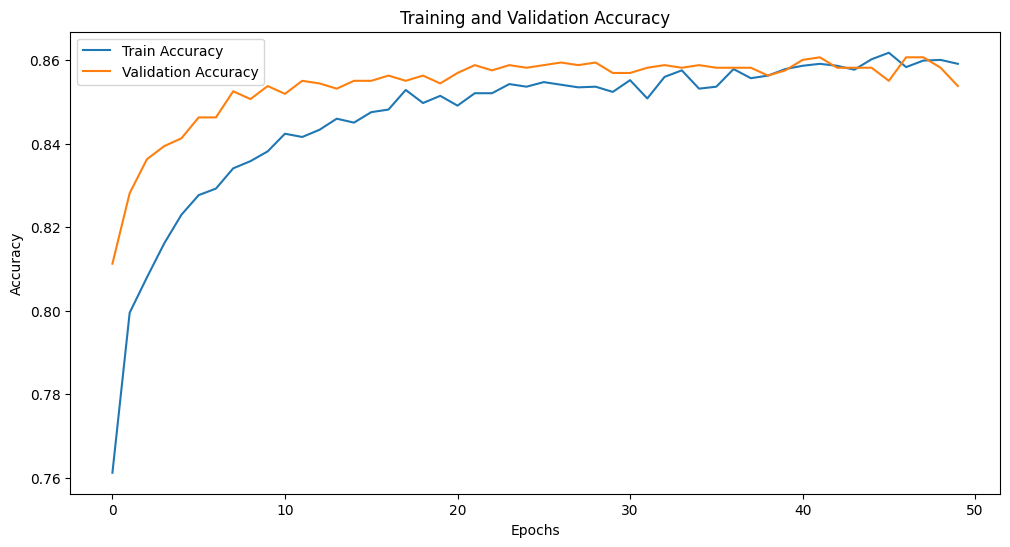

In [33]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
